# WVS + V-Dem + ILO SocProt: Public vs. Private Sector Workers & Institutional Independence

This notebook demonstrates the three harmonized datasets built to test the hypothesis:

> **Public-sector workers in low-social-protection / high-inequality developing democratizers show lower institutional independence orientation than comparable private-sector workers.**

Three datasets are provided:
1. **WVS Wave 7 — developing democratizers** (individual-level): employment sector × institutional trust × SocProt/Gini quadrant  
2. **V-Dem democracy indicators** (country-year): electoral democracy, judicial corruption, civil liberties  
3. **ILO SocProt coverage** (country-year): SDG 1.3.1 social protection coverage (% population)

The core variable is the `institutional_independence_index` — mean of inverted trust scores for judiciary, government, and political parties (higher = more independent orientation).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is NOT pre-installed on Colab — always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import csv
import math
from pathlib import Path
from loguru import logger
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Data Loading

Load the curated demo subset from GitHub (falls back to local file when running locally).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-395f4e-education-inequality-and-democratic-eros/main/round-2/dataset-2/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
for ds in data["datasets"]:
    print(f"Dataset: {ds['dataset']}  —  {len(ds['examples'])} examples")

Dataset: wvs_wave7_developing_democratizers  —  30 examples
Dataset: ilo_socprot_country_year  —  20 examples
Dataset: vdem_democracy_indicators  —  20 examples


## Config

No ML training parameters — this is a data-processing pipeline. The config below controls which
dataset slice to analyze and the quadrant classification cutoffs. These match the values used
to build the full dataset (median SocProt=39.0%, median Gini=37.9).

In [5]:
# ── Quadrant classification cutoffs (from full dataset medians) ───────────────
SP_MEDIAN = 39.0   # social protection coverage median (%)
GINI_MEDIAN = 37.9 # Gini median

# ── Which dataset to inspect ──────────────────────────────────────────────────
PRIMARY_DATASET = "wvs_wave7_developing_democratizers"

# ── Sector comparison focus ───────────────────────────────────────────────────
FOCUS_QUADRANT = "low_socprot_high_gini"  # primary quadrant for hypothesis test
SECTORS_TO_COMPARE = ["public", "private"]

## Dataset 1: WVS Wave 7 — Individual-level Survey Data

The primary dataset. Each row is one WVS Wave 7 respondent from a non-OECD developing democratizer
(V-Dem electdem ≥ 0.35). Key variables:

- **employment sector**: public / private / ngo (from Q284)
- **institutional trust**: judiciary (Q69), government (Q71), parties (Q72) — *inverted* so higher = more independent
- **institutional_independence_index**: mean of the three inverted trust components
- **quadrant**: classified by country-level SocProt × Gini relative to sample medians


In [6]:
# Extract WVS examples into a DataFrame
wvs_ds = next(ds for ds in data["datasets"] if ds["dataset"] == PRIMARY_DATASET)
wvs_examples = wvs_ds["examples"]

wvs_df = pd.DataFrame([
    {
        "country": ex["metadata_country_iso3"],
        "year": ex["metadata_year"],
        "sector": ex["metadata_employment_sector"],
        "education": ex["metadata_education"],
        "income_quintile": ex["metadata_income_quintile"],
        "socprot_coverage": ex["metadata_socprot_coverage"],
        "gini": ex["metadata_gini"],
        "quadrant": ex["metadata_quadrant"],
        "trust_judiciary": ex["metadata_trust_judiciary"],
        "trust_government": ex["metadata_trust_government"],
        "trust_parties": ex["metadata_trust_parties"],
        "democracy_preference": ex["metadata_democracy_preference"],
        "democracy_importance": ex["metadata_democracy_importance"],
        "iii": ex["metadata_institutional_independence_index"],
    }
    for ex in wvs_examples
])

print(f"WVS rows: {len(wvs_df)}")
print(f"Countries: {sorted(wvs_df['country'].unique())}")
print(f"Sectors: {wvs_df['sector'].value_counts().to_dict()}")
print(f"Quadrants: {wvs_df['quadrant'].value_counts().to_dict()}")
wvs_df.head(5)

WVS rows: 30
Countries: ['ARG', 'ARM', 'BOL', 'BRA', 'CYP', 'ECU', 'GTM', 'IDN', 'IND', 'IRQ', 'MMR', 'TWN']
Sectors: {'private': 11, 'public': 11, 'ngo': 8}
Quadrants: {'low_socprot_high_gini': 12, 'high_socprot_low_gini': 10, 'high_socprot_high_gini': 6, 'low_socprot_low_gini': 2}


,country,year,sector,education,income_quintile,socprot_coverage,gini,quadrant,trust_judiciary,trust_government,trust_parties,democracy_preference,democracy_importance,iii
0,ARG,2017,ngo,1,1,67.0,37.9,high_socprot_low_gini,1,1.0,1,None,None,0.3333
1,ARG,2017,private,1,1,67.0,37.9,high_socprot_low_gini,2,2.0,1,None,None,0.5556
2,ARG,2017,public,1,2,67.0,37.9,high_socprot_low_gini,3,3.0,3,None,None,1.0000
3,ARM,2021,private,3,2,54.4,34.0,high_socprot_low_gini,3,3.0,2,None,None,0.8889
4,ARM,2021,public,3,2,54.4,34.0,high_socprot_low_gini,3,3.0,3,None,None,1.0000


## Dataset 2: V-Dem Democracy Indicators

Country-year panel of V-Dem v16 democracy scores for non-OECD developing democratizers (electdem ≥ 0.2),
years 2010–2022. Used to validate the developing-democratizer classification and provide macro context
on institutional quality (judicial/executive corruption, civil liberties).

In [7]:
# Extract V-Dem examples
vdem_ds = next(ds for ds in data["datasets"] if ds["dataset"] == "vdem_democracy_indicators")
vdem_examples = vdem_ds["examples"]

vdem_df = pd.DataFrame([
    {
        "country": ex["metadata_country_iso3"],
        "year": ex["metadata_year"],
        "electdem_vdem": ex["metadata_electdem_vdem"],
        "corr_jud_vdem": ex["metadata_corr_jud_vdem"],
        "corr_exec_vdem": ex["metadata_corr_exec_vdem"],
        "civ_libs_vdem": ex["metadata_civ_libs_vdem"],
    }
    for ex in vdem_examples
])

print(f"V-Dem rows: {len(vdem_df)}")
print(f"Countries: {sorted(vdem_df['country'].unique())}")
vdem_df.head(5)

V-Dem rows: 20
Countries: ['AFG', 'AGO', 'ALB', 'ARG', 'ARM', 'AZE', 'BEN', 'BFA', 'BGD', 'BGR', 'BIH', 'BLR', 'BOL', 'BRA', 'BWA', 'CMR', 'CYP', 'DZA', 'HRV', 'KHM']


,country,year,electdem_vdem,corr_jud_vdem,corr_exec_vdem,civ_libs_vdem
0,AFG,2010,0.353,-2.034,0.932,0.542
1,ALB,2010,0.550,-1.049,0.736,0.878
2,DZA,2010,0.322,-0.526,0.654,0.594
3,AGO,2010,0.214,-1.107,0.935,0.503
4,ARG,2010,0.761,-0.414,0.689,0.901


## Dataset 3: ILO Social Protection Coverage

Country-year social protection coverage (% population covered) from the ILO SDG 1.3.1 indicator
via DBnomics. This is the primary axis for classifying countries into SocProt quadrants: countries
below the median (39.0%) are "low_socprot".

In [8]:
# Extract ILO SocProt examples
ilo_ds = next(ds for ds in data["datasets"] if ds["dataset"] == "ilo_socprot_country_year")
ilo_examples = ilo_ds["examples"]

ilo_df = pd.DataFrame([
    {
        "country": ex["metadata_country_iso3"],
        "year": ex["metadata_year"],
        "socprot_coverage": ex["metadata_socprot_coverage"],
    }
    for ex in ilo_examples
])

print(f"ILO SocProt rows: {len(ilo_df)}")
print(f"Countries: {sorted(ilo_df['country'].unique())}")
print(f"Coverage range: {ilo_df['socprot_coverage'].min():.1f}% – {ilo_df['socprot_coverage'].max():.1f}%")
ilo_df.head(5)

ILO SocProt rows: 20
Countries: ['ABW', 'AFG', 'AGO', 'AIA', 'ALB', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLR']
Coverage range: 3.5% – 100.0%


,country,year,socprot_coverage
0,ABW,2020,87.0
1,AFG,2020,7.5
2,AGO,2017,9.9
3,AIA,2019,57.7
4,ALB,2021,77.6


## Helper Functions (from original script)

Utility functions used during data construction — reproduced here for reference and to show
how the institutional independence index and quadrant labels are derived.

In [9]:
def _safe_int(val, missing_vals=None):
    if missing_vals is None:
        missing_vals = {"-1", "-2", "-3", "-4", "-5", "-6", "-7", "-8", "-9"}
    if val is None:
        return None
    s = str(val).strip()
    if s in missing_vals or s == "" or s.lower() in {"nan", "none"}:
        return None
    try:
        return int(float(s))
    except (ValueError, TypeError):
        return None


def _safe_float(val):
    if val is None:
        return None
    try:
        f = float(val)
        return None if math.isnan(f) else f
    except (ValueError, TypeError):
        return None


def _nearest_year(lookup: dict, year: int, max_gap: int = 3):
    """Return value from lookup for nearest year within max_gap."""
    if year in lookup:
        return lookup[year]
    best_val, best_dist = None, max_gap + 1
    for yr, val in lookup.items():
        d = abs(yr - year)
        if d < best_dist:
            best_dist, best_val = d, val
    return best_val


# Trust inversion: WVS scale 1=great deal → 4=none at all; invert so higher = more independent
def trust_val(v):
    v = _safe_int(v)
    if v is None or v < 1 or v > 4:
        return None
    return 5 - v  # invert: 4=high independence orientation, 1=low


# Quadrant classification (mirrors the logic in process_wvs)
def classify_quadrant(sp, gini, sp_med=SP_MEDIAN, gini_med=GINI_MEDIAN):
    if sp < sp_med and gini > gini_med:
        return "low_socprot_high_gini"
    elif sp < sp_med:
        return "low_socprot_low_gini"
    elif gini > gini_med:
        return "high_socprot_high_gini"
    else:
        return "high_socprot_low_gini"

print("Helper functions defined.")

Helper functions defined.


## Quadrant Analysis: SocProt × Gini Classification

Each WVS respondent's country is classified into one of four quadrants based on the country's
social protection coverage and Gini coefficient relative to the developing-democratizer sample medians.
The **primary quadrant** for the hypothesis test is `low_socprot_high_gini` (9 countries: ECU, GTM, IDN, IND, KEN, MYS, NGA, PER, PHL).

In [10]:
# Quadrant distribution across the demo subset
quadrant_counts = wvs_df["quadrant"].value_counts()
print("Quadrant distribution:")
for q, n in quadrant_counts.items():
    marker = " ← primary" if q == FOCUS_QUADRANT else ""
    print(f"  {q:<35} {n:>3}{marker}")

# Country coverage per quadrant
print("\nCountries in primary quadrant:")
primary_countries = sorted(wvs_df[wvs_df["quadrant"] == FOCUS_QUADRANT]["country"].unique())
print(" ", primary_countries)

Quadrant distribution:
  low_socprot_high_gini                12 ← primary
  high_socprot_low_gini                10
  high_socprot_high_gini                6
  low_socprot_low_gini                  2

Countries in primary quadrant:
  ['ECU', 'GTM', 'IDN', 'IND']


## Sector Comparison: Institutional Independence Index

The core hypothesis test: compare the mean `institutional_independence_index` between public-sector
and private-sector workers. The hypothesis predicts that in the `low_socprot_high_gini` quadrant,
public workers show **lower** index values (less independent orientation) than private workers.

In [11]:
# Mean institutional independence index by sector × quadrant
sector_quadrant = (
    wvs_df[wvs_df["sector"].isin(SECTORS_TO_COMPARE)]
    .groupby(["quadrant", "sector"])["iii"]
    .agg(["mean", "count"])
    .round(4)
)
print("Mean institutional independence index (public vs private):")
print(sector_quadrant.to_string())

# Highlight the primary quadrant gap
print("\nPrimary quadrant gap (public − private):")
pq = wvs_df[(wvs_df["quadrant"] == FOCUS_QUADRANT) & (wvs_df["sector"].isin(SECTORS_TO_COMPARE))]
if len(pq) > 0:
    gap = pq.groupby("sector")["iii"].mean()
    for s in SECTORS_TO_COMPARE:
        if s in gap:
            print(f"  {s:<10} mean III = {gap[s]:.4f}  (n={len(pq[pq['sector']==s])})")
    if all(s in gap for s in SECTORS_TO_COMPARE):
        diff = gap["public"] - gap["private"]
        print(f"  Δ (public − private) = {diff:+.4f}  {'← confirms hypothesis' if diff < 0 else '← contradicts hypothesis'}")
else:
    print("  (no primary-quadrant examples in this demo subset)")

Mean institutional independence index (public vs private):
                                  mean  count
quadrant               sector                
high_socprot_high_gini private  0.6111      2
                       public   0.5000      2
high_socprot_low_gini  private  0.7500      4
                       public   0.9167      4
low_socprot_high_gini  private  0.7500      4
                       public   0.6111      4
low_socprot_low_gini   private  0.3333      1
                       public   0.7778      1

Primary quadrant gap (public − private):
  public     mean III = 0.6111  (n=4)
  private    mean III = 0.7500  (n=4)
  Δ (public − private) = -0.1389  ← confirms hypothesis


## Results Visualization

Three panels:
1. Mean institutional independence index by sector across all quadrants  
2. SocProt coverage distribution (ILO data)  
3. Electoral democracy scores by country (V-Dem)

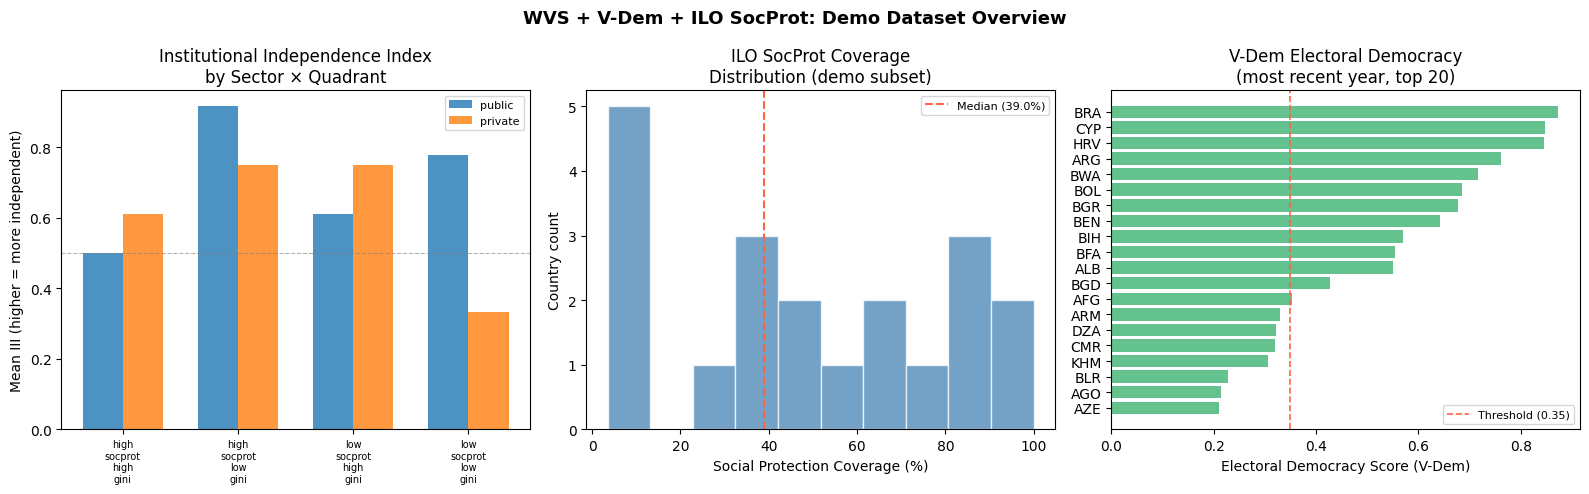

Saved results_overview.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("WVS + V-Dem + ILO SocProt: Demo Dataset Overview", fontsize=13, fontweight="bold")

# ── Panel 1: III by sector × quadrant ────────────────────────────────────────
ax1 = axes[0]
plot_df = (
    wvs_df[wvs_df["sector"].isin(SECTORS_TO_COMPARE)]
    .groupby(["quadrant", "sector"])["iii"]
    .mean()
    .unstack("sector")
)
if not plot_df.empty:
    x = range(len(plot_df))
    w = 0.35
    for i, sector in enumerate(SECTORS_TO_COMPARE):
        if sector in plot_df.columns:
            bars = ax1.bar(
                [xi + i * w for xi in x],
                plot_df[sector],
                w,
                label=sector,
                alpha=0.8,
            )
    ax1.set_xticks([xi + w / 2 for xi in x])
    ax1.set_xticklabels([q.replace("_", "\n") for q in plot_df.index], fontsize=7)
    ax1.set_ylabel("Mean III (higher = more independent)")
    ax1.set_title("Institutional Independence Index\nby Sector × Quadrant")
    ax1.legend(fontsize=8)
    ax1.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
else:
    ax1.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax1.transAxes)
    ax1.set_title("Institutional Independence Index")

# ── Panel 2: ILO SocProt coverage distribution ───────────────────────────────
ax2 = axes[1]
ax2.hist(ilo_df["socprot_coverage"], bins=10, color="steelblue", alpha=0.75, edgecolor="white")
ax2.axvline(SP_MEDIAN, color="tomato", linestyle="--", linewidth=1.5, label=f"Median ({SP_MEDIAN}%)")
ax2.set_xlabel("Social Protection Coverage (%)")
ax2.set_ylabel("Country count")
ax2.set_title("ILO SocProt Coverage\nDistribution (demo subset)")
ax2.legend(fontsize=8)

# ── Panel 3: V-Dem electdem scores ───────────────────────────────────────────
ax3 = axes[2]
vdem_latest = vdem_df.sort_values("year").groupby("country").last().reset_index()
vdem_latest = vdem_latest.sort_values("electdem_vdem", ascending=False).head(20)
ax3.barh(vdem_latest["country"], vdem_latest["electdem_vdem"], color="mediumseagreen", alpha=0.8)
ax3.axvline(0.35, color="tomato", linestyle="--", linewidth=1.2, label="Threshold (0.35)")
ax3.set_xlabel("Electoral Democracy Score (V-Dem)")
ax3.set_title("V-Dem Electoral Democracy\n(most recent year, top 20)")
ax3.legend(fontsize=8)
ax3.invert_yaxis()

plt.tight_layout()
plt.savefig("results_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved results_overview.png")